## Linear Classifier in TensorFlow 
Using Low Level API in Eager Execution mode

In [0]:
#In Tensorflow 2.0, eager execution is enabled by default. 
#However, we will verify after loading tensorflow 2

Tensor Flow Version 2.x [We donot want to use 1.x version which is the default]

In [0]:
%tensorflow_version 2.x

### Load tensorflow

In [0]:
import tensorflow as tf


In [1035]:
# Ensure TensorFlow version 2.x
print(tf.__version__)

2.1.0-rc1


In [1036]:
#Ensure that Eager Execution Mode is enabled [by default]
tf.executing_eagerly()

True

In [1037]:
tf.test.gpu_device_name()

''

#Enable Eager Execution if using tensflow version < 2.0
#From tensorflow v2.0 onwards, Eager Execution will be enabled by default


### Collect Data

In [1038]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
import pandas as pd

In [0]:
price_df = pd.read_csv('/content/drive/My Drive/GreatLakes/NeuralNetwork/LabResidency6/prices.csv')

### Check all columns in the dataset

In [1041]:
price_df.describe().T
#Total count of observations is 851264 
# 'open' column mean > median indicating right skew
# 'close' column mean > median indicating right skew
# 'open' and 'close' columns have similar values
# 'low' column has mean > median indicating right skew
# 'high' column  has mean >median indicating right skew

,count,mean,std,min,25%,50%,75%,max
open,851264.0,7.083699e+01,8.369588e+01,0.85,3.384000e+01,5.277000e+01,7.988000e+01,1.584440e+03
close,851264.0,7.085711e+01,8.368969e+01,0.86,3.385000e+01,5.280000e+01,7.989000e+01,1.578130e+03
low,851264.0,7.011841e+01,8.287729e+01,0.83,3.348000e+01,5.223000e+01,7.911000e+01,1.549940e+03
high,851264.0,7.154348e+01,8.446550e+01,0.88,3.419000e+01,5.331000e+01,8.061000e+01,1.600930e+03
volume,851264.0,5.415113e+06,1.249468e+07,0.00,1.221500e+06,2.476250e+06,5.222500e+06,8.596434e+08


In [1042]:
price_df.describe(include='object')
# Data and symbol are object type(categorical)

,date,symbol
count,851264,851264
unique,3524,501
top,2016-04-05,WFM
freq,498,1762


In [1043]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
date      851264 non-null object
symbol    851264 non-null object
open      851264 non-null float64
close     851264 non-null float64
low       851264 non-null float64
high      851264 non-null float64
volume    851264 non-null float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB


In [1044]:
#Check missing values
price_df.isna().any()
#No missing values exist

date      False
symbol    False
open      False
close     False
low       False
high      False
volume    False
dtype: bool

In [0]:
#Checking all the columns
import seaborn as sns

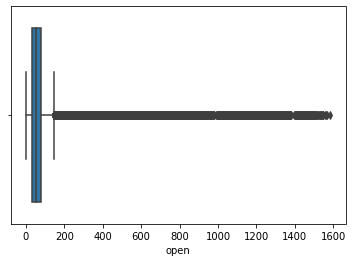

In [1046]:
sns.boxplot(price_df['open'])

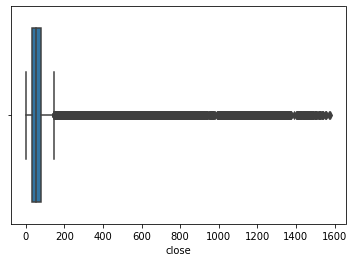

In [1047]:
sns.boxplot(price_df['close'])

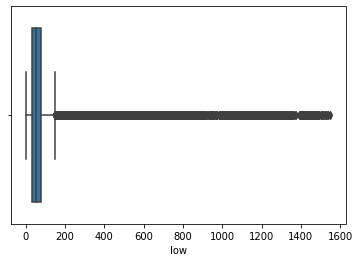

In [1048]:
sns.boxplot(price_df['low'])

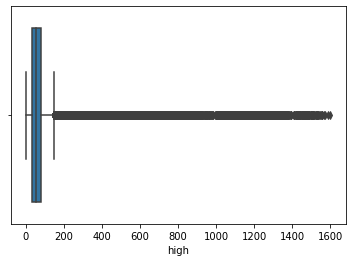

In [1049]:
sns.boxplot(price_df['high'])

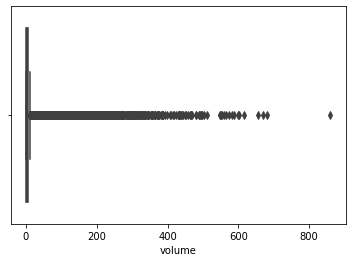

In [1050]:
sns.boxplot(price_df['volume']/1000000)

In [0]:
# Box plots confirms right skew in al the columns and considerable outliers.
#Because of extreme skew we will pick a subset and analyze the subset dataset
#pairplot not visualizing here

### Drop columns `date` and  `symbol`

In [0]:
price_df.drop(columns=['date','symbol'],axis=1,inplace=True,errors='ignore')

In [1053]:
print(price_df.columns)
#date and symbol have been dropped

Index(['open', 'close', 'low', 'high', 'volume'], dtype='object')


### Consider only first 1000 rows in the dataset for building feature set and target set
Target 'Volume' has very high values. Divide 'Volume' by 1000,000

In [1054]:
#Take 1000 top rows as dataset for building features and target set
price_subset_df = price_df.iloc[0:1000] 
price_subset_df.shape

(1000, 5)

In [0]:
# Columns open, close, low, high are part of feature subset
price_feature_set = price_subset_df.iloc[:,0:4]

In [1056]:
price_feature_set.shape

(1000, 4)

In [0]:
#volume is target
price_target_set = price_subset_df.loc[:,'volume']

In [1058]:
price_target_set.shape

(1000,)

In [1059]:
price_target_set.describe()
# Max, mean and median are very large values

count    1.000000e+03
mean     5.314222e+06
std      1.446565e+07
min      1.000000e+04
25%      8.216250e+05
50%      2.064450e+06
75%      4.620475e+06
max      2.156202e+08
Name: volume, dtype: float64

In [0]:
price_target_set /= 1000000

In [1061]:
price_target_set.describe()
#Now the values are considerably reduced

count    1000.000000
mean        5.314222
std        14.465650
min         0.010000
25%         0.821625
50%         2.064450
75%         4.620475
max       215.620200
Name: volume, dtype: float64

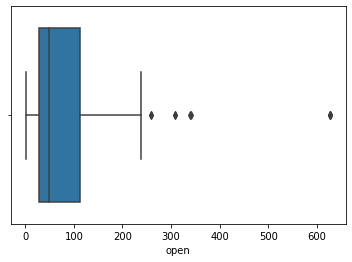

In [1062]:
sns.boxplot(price_feature_set['open'])
#Feature set shows better distributon with 1000 rows
#Not drawing rest of the booxplots for other features. similar distribution expected

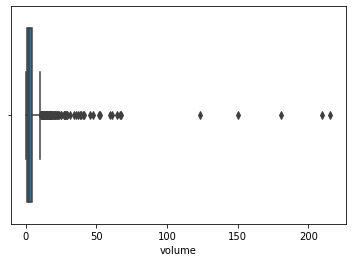

In [1063]:
sns.boxplot(price_target_set)

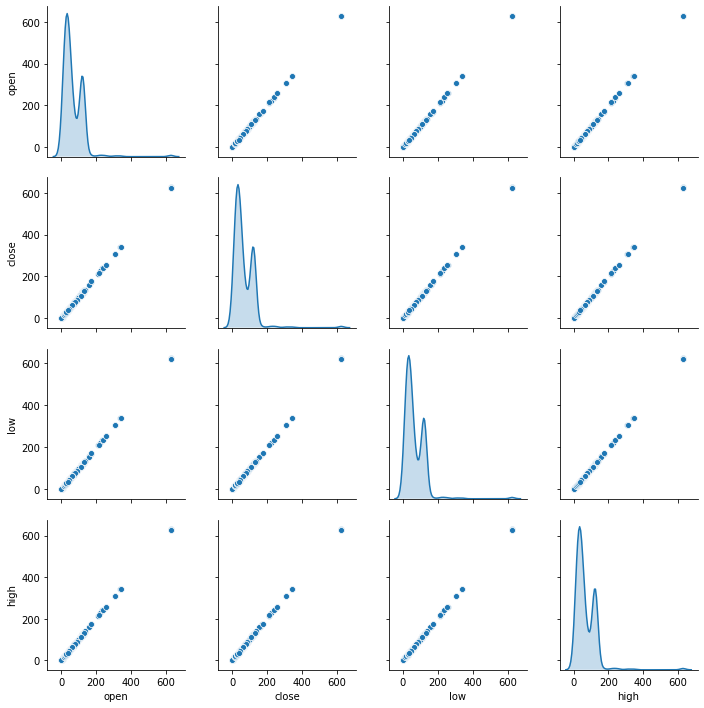

In [1064]:
sns.pairplot(price_feature_set, diag_kind='kde')
#Strong collinearity amongst features

### Divide the data into train and test sets

In [0]:
from sklearn.model_selection import train_test_split


In [1066]:
#Divide the data into train and test with test being roughly 30% of total size
Xtrain,Xtest, ytrain,ytest = train_test_split(price_feature_set, price_target_set, test_size=0.30, random_state=7)
print(Xtrain.shape)
print(Xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(700, 4)
(300, 4)
(700,)
(300,)


#### Convert Training and Test Data to numpy float32 arrays


In [0]:
import numpy as np
Xtrain = (Xtrain.to_numpy()).astype(np.float32)
Xtest = (Xtest.to_numpy()).astype(np.float32)
ytrain = (ytrain.to_numpy()).astype(np.float32)
ytest = (ytest.to_numpy()).astype(np.float32)

In [1068]:
print("X Train type ",type(Xtrain))
print("X Train shape ",Xtrain.shape)
print("X Test type ",type(Xtest))
print("X Test shape ",Xtest.shape)
print("y Train type ",type(ytrain))
print("y Train shape ",ytrain.shape)
print("y Test type ",type(ytest))
print("y Test shape ",ytest.shape)

X Train type  <class 'numpy.ndarray'>
X Train shape  (700, 4)
X Test type  <class 'numpy.ndarray'>
X Test shape  (300, 4)
y Train type  <class 'numpy.ndarray'>
y Train shape  (700,)
y Test type  <class 'numpy.ndarray'>
y Test shape  (300,)


### Normalize the data
You can use Normalizer from sklearn.preprocessing

In [0]:
from sklearn.preprocessing import normalize
Xtrain = normalize(Xtrain, norm='l2', axis=0, copy=False, return_norm=False)
Xtest = normalize(Xtest, norm='l2', axis=0, copy=False, return_norm=False)


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f9a167f7f60>,
      dtype=object)

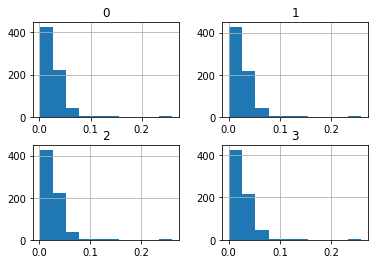

In [1070]:
pd.DataFrame(Xtrain).hist()

## Building the Model in tensorflow

1.Define Weights and Bias, use tf.zeros to initialize weights and Bias

In [0]:
W = tf.zeros(shape=(4,1))#Dimension of tensor = (No of Features X 1 column)
b = tf.zeros(shape=(1))

2.Define a function to calculate prediction

In [0]:
#@title
@tf.function
def getprediction(W, b, features):
  #y = weight*feature + bias
  y_predict = (tf.add(tf.matmul(features, W),b))
  return y_predict

3.Loss (Cost) Function [Mean square error]

In [0]:
@tf.function
def cost(y_actual, y_predicted):
  error = y_actual - y_predicted
  squarederror = tf.square(error)
  MSE = tf.reduce_mean(squarederror)
  return MSE

4.Function to train the Model

1.   Record all the mathematical steps to calculate Loss
2.   Calculate Gradients of Loss w.r.t weights and bias
3.   Update Weights and Bias based on gradients and learning rate to minimize loss

In [0]:
@tf.function
def train(x, y_actual, w, b, learning_rate=0.01):
    print(x.shape)
    print(y_actual.shape)
    # Record mathematical operations on 'tape' to calculate loss
    with tf.GradientTape() as t:
        t.watch([w,b])
        current_prediction = getprediction(w, b, x)
        current_loss = cost(y_actual, current_prediction)
    
    # Calculate Gradients for Loss with respect to Weights and Bias
    dw, db = t.gradient(current_loss,[w, b])
    
    # Update Weights and Bias
    w = w - learning_rate * dw
    b = b - learning_rate * db
    #print("after train")
    return w, b

## Train the model for 100 epochs 
1. Observe the training loss at every iteration
2. Observe Train loss at every 5th iteration

In [1075]:
for i in range (100):
  #Train with actual features and corresponding actual target values
  # At first iteration, W and b have been initialized to 0 earlier
 # print("W",W)
  W, b = train(Xtrain, ytrain, W, b)
  y_predicted = getprediction(W, b, Xtrain)
  
  mse = cost(ytrain, y_predicted)
  print('Training Loss on iteration', i, mse.numpy())
  #After every fifth iteration loss value changing by 1 unit

(700, 4)
(700,)
Training Loss on iteration 0 304.17874
Training Loss on iteration 1 302.97803
Training Loss on iteration 2 301.82492
Training Loss on iteration 3 300.7177
Training Loss on iteration 4 299.6546
Training Loss on iteration 5 298.6336
Training Loss on iteration 6 297.65323
Training Loss on iteration 7 296.7117
Training Loss on iteration 8 295.80768
Training Loss on iteration 9 294.93954
Training Loss on iteration 10 294.10587
Training Loss on iteration 11 293.3054
Training Loss on iteration 12 292.53668
Training Loss on iteration 13 291.79846
Training Loss on iteration 14 291.08957
Training Loss on iteration 15 290.40887
Training Loss on iteration 16 289.75522
Training Loss on iteration 17 289.1275
Training Loss on iteration 18 288.5248
Training Loss on iteration 19 287.9459
Training Loss on iteration 20 287.39014
Training Loss on iteration 21 286.85635
Training Loss on iteration 22 286.34378
Training Loss on iteration 23 285.85156
Training Loss on iteration 24 285.379
Trai

### Get the shapes and values of W and b

In [1076]:
print("Shape of W ",W.shape)

Shape of W  (4, 1)


In [1077]:
print("Shape of b ",b.shape)

Shape of b  (1,)


In [1078]:
print("Final values of weights :\n ",W.numpy())

Final values of weights :
  [[0.13683139]
 [0.1369657 ]
 [0.13671075]
 [0.13707769]]


In [1079]:
print("Final values of bias :\n ",b.numpy())

Final values of bias :
  [4.8555474]


### Model Prediction on 1st Examples in Test Dataset

In [1080]:
#Once we have final value of weights and bias, let us predict for test dataset
ytest_predicted = getprediction(W, b, Xtest)
#Comparing actual and predicted values
print("Prediction for ",Xtest[0]," is ",ytest_predicted[0].numpy())
print("Actual value for ",Xtest[0]," is ",ytest[0])
#Results are matching

Prediction for  [0.03867404 0.03772479 0.03784709 0.03853459]  is  [4.8764625]
Actual value for  [0.03867404 0.03772479 0.03784709 0.03853459]  is  4.8994


## Classification using tf.Keras

In this exercise, we will build a Deep Neural Network using tf.Keras. We will use Iris Dataset for this exercise.

In [0]:
%tensorflow_version 2.x

In [1082]:
tf.__version__

'2.1.0-rc1'

In [1083]:
tf.keras.__version__

'2.2.4-tf'

### Load the given Iris data using pandas (Iris.csv)

In [0]:
import pandas as pd
iris_df = pd.read_csv("/content/drive/My Drive/GreatLakes/NeuralNetwork/LabResidency6/Iris.csv")

In [1085]:
iris_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sepal Length (in cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
Sepal Width in (cm),150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
Petal length (in cm),150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
Petal width (in cm),150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [1086]:
iris_df.shape

(150, 5)

In [1087]:
iris_df.describe(include=object)

,Class
count,150
unique,3
top,Iris-versicolor
freq,50


In [1088]:
iris_df['Class'].value_counts()

Iris-versicolor    50
Iris-setosa        50
Iris-virginica     50
Name: Class, dtype: int64

In [1089]:
iris_df.head()

,Sepal Length (in cm),Sepal Width in (cm),Petal length (in cm),Petal width (in cm),Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


###Checking if species are linearly separable

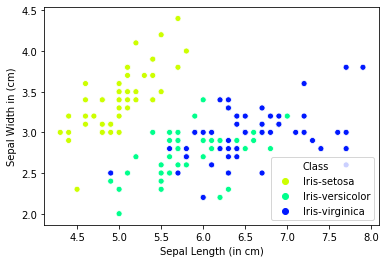

In [1090]:
sns.scatterplot(x='Sepal Length (in cm)', y ='Sepal Width in (cm)', 
                  hue='Class',data=iris_df, palette='gist_rainbow')

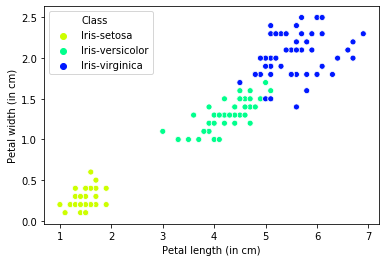

In [1091]:
sns.scatterplot(x='Petal length (in cm)', y ='Petal width (in cm)', 
                  hue='Class',data=iris_df, palette='gist_rainbow')

#####iris-steosa is clearly linearly separable from iris-versicolor and iris-virginica based on petal and sepal length and width. iris-setosa has smaller petal length and width. iris-setosa has smaller sepal length and higher sepal width.
iris-versicolor and iris-virginica are linearly separable based on petal length and petal width but not based on sepal length and width. 


### Target set has different categories. So, Label encode them. And convert into one-hot vectors using get_dummies in pandas.

In [0]:
iris_df_encoded = pd.get_dummies(iris_df,columns =['Class'], drop_first=False)

In [1093]:
iris_df_encoded.head()

,Sepal Length (in cm),Sepal Width in (cm),Petal length (in cm),Petal width (in cm),Class_Iris-setosa,Class_Iris-versicolor,Class_Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


In [1094]:
iris_df_encoded.tail()

,Sepal Length (in cm),Sepal Width in (cm),Petal length (in cm),Petal width (in cm),Class_Iris-setosa,Class_Iris-versicolor,Class_Iris-virginica
145,6.7,3.0,5.2,2.3,0,0,1
146,6.3,2.5,5.0,1.9,0,0,1
147,6.5,3.0,5.2,2.0,0,0,1
148,6.2,3.4,5.4,2.3,0,0,1
149,5.9,3.0,5.1,1.8,0,0,1


In [1095]:
iris_df_encoded.shape

(150, 7)

### Splitting the data into feature set and target set

In [0]:
feature_set = iris_df_encoded.iloc[:,0:4]

In [1097]:
feature_set.shape

(150, 4)

In [0]:
target_set = iris_df_encoded.iloc[:, 4:7 ]

In [1099]:
target_set.shape

(150, 3)

In [1100]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest, ytrain,ytest = train_test_split(feature_set, target_set, test_size=0.30, random_state=7)
print("Xtrain shape",Xtrain.shape)
print("Xtest shape",Xtest.shape)
print("ytrain shape",ytrain.shape)
print("ytest shape",ytest.shape)

Xtrain shape (105, 4)
Xtest shape (45, 4)
ytrain shape (105, 3)
ytest shape (45, 3)


###  Building Model in tf.keras

Build a Linear Classifier model  <br>
1.  Use Dense Layer  with input shape of 4 (according to the feature set) and number of outputs set to 3<br> 
2. Apply Softmax on Dense Layer outputs <br>
3. Use SGD as Optimizer
4. Use categorical_crossentropy as loss function 

**AD Approach :**Trying to solve the problem with  1 hidden layer and two hidden layers network for comparison
##### MULTI LAYER NEURAL NETWORKS - Have one layer of input nodes, one or more hidden/dense layers and one layer of output nodes. We will try with one layer of hidden layer as well as 2 layer of hidden layers and dont extend beyond that


In [0]:
#Multilayer neural network with one hidden layer

In [0]:
#It is sequential because it involves creating a model and then adding layers to it one by one
# from left to right
model = tf.keras.models.Sequential()
#print(Xtrain.shape[1])

In [0]:
#The Sequential model accepts 4 inputs, has one hidden layer, and 
#then an output layer with three nodes to predict three classes of iris.

# Model accepts 4 inputs and here we are adding various counts of neurons in hidden layer 
# [check the comments for each value of neuron]. Best accuracy was with 3 neurons in hidden layer

#With 2 neurons in hidden layer, train accuracy was 68.5
#model.add(tf.keras.layers.Dense(2, input_shape=(4,)))

#With 3 neurons in hidden layer, train accuracy was 97.1
model.add(tf.keras.layers.Dense(3, input_shape=(Xtrain.shape[1],)))

#With 4 neurons in hidden layer, train accuracy was 81.90
#model.add(tf.keras.layers.Dense(4, input_shape=(4,)))

In [0]:
# Add Dense Layer which provides 3 Outputs after applying softmax
model.add(tf.keras.layers.Dense(3, activation='softmax'))

In [0]:
#Before training a model, you need to configure the learning process, which is done via 
#the compile method. Going with defult learning rate provided by SGD.
# Value of learning rate = 
model.compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


### Model Training 

In [1106]:
# Train the model
model.fit(Xtrain, ytrain, epochs=100, batch_size=32)

Train on 105 samples
Epoch 1/100
105/105 [==============================] - 0s 2ms/sample - loss: 2.9981 - accuracy: 0.0000e+00
Epoch 2/100
105/105 [==============================] - 0s 105us/sample - loss: 2.1190 - accuracy: 0.1048
Epoch 3/100
105/105 [==============================] - 0s 101us/sample - loss: 1.5752 - accuracy: 0.1905
Epoch 4/100
105/105 [==============================] - 0s 96us/sample - loss: 1.2532 - accuracy: 0.3048
Epoch 5/100
105/105 [==============================] - 0s 98us/sample - loss: 1.1561 - accuracy: 0.2571
Epoch 6/100
105/105 [==============================] - 0s 119us/sample - loss: 1.0767 - accuracy: 0.2952
Epoch 7/100
105/105 [==============================] - 0s 93us/sample - loss: 1.0143 - accuracy: 0.3048
Epoch 8/100
105/105 [==============================] - 0s 102us/sample - loss: 0.9652 - accuracy: 0.3238
Epoch 9/100
105/105 [==============================] - 0s 78us/sample - loss: 0.9111 - accuracy: 0.4381
Epoch 10/100
105/105 [==============

In [1107]:
model.summary()

Model: "sequential_23"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_53 (Dense)             (None, 3)                 15        
_________________________________________________________________
dense_54 (Dense)             (None, 3)                 12        
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


###Evaluate the model

In [1108]:
loss, acc = model.evaluate(Xtest, ytest, verbose=0)
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 0.911


### Model Prediction

In [1109]:
featurevalue = [5,2,3,1] #Picked values from scatter plots drawn above. It should be iris-versicolor
                          # predicton result was 1
#featurevalue = [4.5,3.0, 1, 0.5] #Picked values from scatter plots drawn above. It should be iris-setosa
                           #prediction result was 0
ypredictclass = model.predict_classes([featurevalue])

print('Predicted class:' ,ypredictclass)
print('Predicted Probability:' ,model.predict([featurevalue]))


Predicted class: [1]
Predicted Probability: [[0.15222275 0.677227   0.17055017]]


### Save the Model

In [1110]:
model.save('iris_model.h5')

# Recreate the exact same model, including weights and optimizer.
new_model = tf.keras.models.load_model('iris_model.h5')
new_model.summary()

Model: "sequential_23"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_53 (Dense)             (None, 3)                 15        
_________________________________________________________________
dense_54 (Dense)             (None, 3)                 12        
Total params: 27
Trainable params: 27
Non-trainable params: 0
_________________________________________________________________


### Build and Train a Deep Neural network with 2 hidden layer  - Optional - For Practice

Does it perform better than Linear Classifier? What could be the reason for difference in performance?

In [0]:
model2 = tf.keras.models.Sequential()

In [0]:
model2.add(tf.keras.layers.Dense(3, input_shape=(4,)))
model2.add(tf.keras.layers.Dense(5))

In [0]:
model2.add(tf.keras.layers.Dense(3, activation='softmax'))

In [1114]:
model2.compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model2.fit(Xtrain, ytrain, epochs=100, batch_size=32)
#Train accuracy is 98.1


Train on 105 samples
Epoch 1/100
105/105 [==============================] - 0s 2ms/sample - loss: 2.6173 - accuracy: 0.3714
Epoch 2/100
105/105 [==============================] - 0s 98us/sample - loss: 1.4037 - accuracy: 0.2762
Epoch 3/100
105/105 [==============================] - 0s 117us/sample - loss: 1.1179 - accuracy: 0.3048
Epoch 4/100
105/105 [==============================] - 0s 102us/sample - loss: 0.9877 - accuracy: 0.3524
Epoch 5/100
105/105 [==============================] - 0s 93us/sample - loss: 0.9229 - accuracy: 0.4571
Epoch 6/100
105/105 [==============================] - 0s 106us/sample - loss: 0.8286 - accuracy: 0.4381
Epoch 7/100
105/105 [==============================] - 0s 102us/sample - loss: 0.8652 - accuracy: 0.6381
Epoch 8/100
105/105 [==============================] - 0s 114us/sample - loss: 0.7777 - accuracy: 0.6571
Epoch 9/100
105/105 [==============================] - 0s 125us/sample - loss: 0.6782 - accuracy: 0.7714
Epoch 10/100
105/105 [================

In [1115]:
loss, acc = model2.evaluate(Xtest, ytest, verbose=0)
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 0.978


In [0]:
#Conclusion: The three species of iris are linearly separable as is evident from the scatter plot
# so the accuracies with one and two hidden layers are very high as not much complexity is there
# There is not much difference in performance (both are above 90%) between one and two hidden layer 
# models. The number of features on which the classes are differentiable are only 4 so adding additional
# hidden layer advantage is not very high   